<a href="https://colab.research.google.com/github/somendrew/LangGraph_tutorial/blob/main/7_Human_in_the_Loop_%E2%80%94_Interrupts_and_Approvals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. What is it?
Human-in-the-loop means pausing the graph mid-execution and waiting for a human to do something — approve a decision, provide input, or correct the AI — before the graph continues. The graph literally freezes in place, waits, then resumes from exactly where it stopped.

## 2. Why does it matter?
Not everything should be fully automated. You need human-in-the-loop when:

* An AI is about to do something irreversible (send an email, delete data, charge a card)
* The AI is unsure and needs a human to confirm
* A compliance or safety rule requires human sign-off
* You want to let users edit or steer the AI mid-task

Without this, your agent acts autonomously even when it shouldn't. With it, you stay in control of the critical moments.

## 3. The Analogy
Think of a surgeon and an anaesthetist before an operation:

* The team preps everything (graph runs up to a point)
* Before the first cut, the surgeon pauses and asks: "Everyone ready? Confirm."
* Only after everyone confirms does the operation proceed
* If someone says no → they stop, reassess, adjust

The pause before the cut is the interrupt. The confirmation is the human resume.

In [3]:
# @title ## Visual
import IPython

html_content = """
<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; padding: 20px; color: #333; display: flex; gap: 50px; justify-content: center; background: #fff; border-radius: 8px;">

    <div style="flex: 1; max-width: 300px; text-align: center; border: 1px solid #e0e0e0; padding: 20px; border-radius: 8px; background: #fafafa;">
        <h3 style="margin-top: 0; color: #5f6368; border-bottom: 2px solid #e0e0e0; padding-bottom: 8px;">WITHOUT INTERRUPT</h3>
        <div style="display: inline-block; padding: 10px 20px; margin: 15px 0; background: #e8f0fe; color: #1a73e8; border-radius: 4px; font-weight: bold;">START</div>
        <div style="font-size: 20px; color: #70757a;">↓</div>
        <div style="display: inline-block; padding: 10px 20px; margin: 15px 0; background: #f1f3f4; border: 1px solid #dadce0; border-radius: 4px; font-family: monospace;">draft_email</div>
        <div style="font-size: 20px; color: #70757a;">↓</div>
        <div style="display: inline-block; padding: 10px 20px; margin: 15px 0; background: #f1f3f4; border: 1px solid #dadce0; border-radius: 4px; font-family: monospace;">send_email</div>
        <div style="font-size: 12px; color: #70757a; font-style: italic; margin-top: -10px;">(no pause)</div>
        <div style="font-size: 20px; color: #70757a;">↓</div>
        <div style="display: inline-block; padding: 10px 20px; margin: 15px 0; background: #fce8e6; color: #c5221f; border-radius: 4px; font-weight: bold;">END</div>
    </div>

    <div style="flex: 1; max-width: 350px; text-align: center; border: 1px solid #e0e0e0; padding: 20px; border-radius: 8px; background: #fafafa;">
        <h3 style="margin-top: 0; color: #5f6368; border-bottom: 2px solid #e0e0e0; padding-bottom: 8px;">WITH INTERRUPT</h3>
        <div style="display: inline-block; padding: 10px 20px; margin: 15px 0; background: #e8f0fe; color: #1a73e8; border-radius: 4px; font-weight: bold;">START</div>
        <div style="font-size: 20px; color: #70757a;">↓</div>
        <div style="display: inline-block; padding: 10px 20px; margin: 15px 0; background: #f1f3f4; border: 1px solid #dadce0; border-radius: 4px; font-family: monospace;">draft_email</div>
        <div style="font-size: 20px; color: #b06000;">👇</div>
        <div style="display: inline-block; padding: 12px; margin: 10px 0; background: #fef7e0; border: 2px dashed #f9ab00; border-radius: 6px; color: #b06000; font-weight: 500;">
            ⏸️ GRAPH FREEZES HERE<br>
            <span style="font-family: monospace; font-size: 12px;">interrupt_before="send_email"</span>
        </div>
        <div style="font-size: 20px; color: #70757a;">↓</div>
        <div style="display: inline-block; padding: 12px 20px; margin: 10px 0; background: #e8f5e9; border: 1px solid #81c784; border-radius: 20px; font-weight: 500;">
            👤 Human Reviews Draft
        </div>

        <div style="display: flex; justify-content: space-between; margin: 15px 0; position: relative;">
            <div style="flex: 1; text-align: left; padding-left: 10px; border-left: 2px solid #dadce0;">
                <span style="color: #c5221f; font-size: 13px; font-weight: bold;">❌ Reject</span><br>
                <span style="font-size: 11px; color: #70757a;">Loops back to edit draft</span>
            </div>
            <div style="flex: 1; text-align: right; padding-right: 10px; border-right: 2px solid #dadce0;">
                <span style="color: #137333; font-size: 13px; font-weight: bold;">✅ Approve</span><br>
                <span style="font-size: 11px; color: #70757a;">Continues execution</span>
            </div>
        </div>

        <div style="font-size: 20px; color: #70757a;">↓</div>
        <div style="display: inline-block; padding: 10px 20px; margin: 10px 0; background: #f1f3f4; border: 1px solid #dadce0; border-radius: 4px; font-family: monospace;">send_email</div>
        <div style="font-size: 20px; color: #70757a;">↓</div>
        <div style="display: inline-block; padding: 10px 20px; margin: 15px 0; background: #fce8e6; color: #c5221f; border-radius: 4px; font-weight: bold;">END</div>
    </div>

</div>
"""

IPython.display.display(IPython.display.HTML(html_content))

## 5. How It Works — Three Key APIs

```
# ── 1. Checkpointer: required for interrupts ──────────────
# Interrupts need a "memory" to save graph state while paused.
# MemorySaver stores it in RAM (fine for dev/testing).
from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()

# ── 2. interrupt_before: pause BEFORE a node runs ─────────
app = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["send_email"]  # freeze before this node
)

# ── 3. Resume with .invoke() again ────────────────────────
# First call: runs until interrupt, then stops
config = {"configurable": {"thread_id": "thread-1"}}
app.invoke(initial_state, config)   # pauses at send_email

# Human reviews here...

# Second call: resume from where it stopped
app.invoke(None, config)            # None = no new input, just resume

```

## Code


Graph pauses before sending email, waits for approval

In [7]:
!pip install -q langgraph Typing langchain_openai langchain_core

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 8.0 MB/s eta 0:00:00


In [8]:
from google.colab import userdata
api_key = userdata.get('api_key')

In [10]:
import os
from typing import TypedDict, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver


os.environ["OPENAI_API_KEY"] = api_key
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)


# 1.State - now include human draft

class SupportState(TypedDict):
  user_message : str
  intent : str
  response : str
  messages : Annotated[list,add_messages]
  email_draft : str  # the draft that human will review
  approved : bool # Did the human approve


# 2. Classify
def classify_intent(state: SupportState) -> dict:
    prompt = f"""Classify into one word: BILLING, TECHNICAL, or GENERAL.
Message: {state['user_message']}"""
    result = llm.invoke(prompt)
    return {"intent": result.content.strip().upper()}

# 3. Draft email node
def draft_email(state:SupportState)->dict:

  """Drafts the support email — human will review this."""

  prompt = f"""Write a professional support email reply.
Issue type: {state['intent']}
Customer message: {state['user_message']}
Keep it under 5 sentences."""

  result = llm.invoke(prompt)
  draft =result.content

  print(f"\n📧 Draft email created:")
  print(f"{'─'*40}")
  print(draft)
  print(f"{'─'*40}")
  print("⏸  Graph is pausing for human review...")

  return {
        "email_draft": draft,
        "messages": [AIMessage(content=draft)],
    }

# ── 4. NEW: Send email node (only runs after approval) ────
def send_email(state: SupportState) -> dict:
    """
    This node only runs if the human approved.
    In real life this would call an email API.
    """
    print(f"\n✅ Email approved and sent!")
    print(f"Final email:\n{state['email_draft']}")
    return {"response": f"Email sent: {state['email_draft']}"}

# ── 5. NEW: Rejected node ─────────────────────────────────
def handle_rejection(state: SupportState) -> dict:
    """Runs if the human rejected the draft."""
    print("\n❌ Email rejected by human. Flagging for manual handling.")
    return {"response": "Email rejected — escalated to senior agent."}

# ── 6. NEW: Router — reads human's approval decision ──────
def route_approval(state: SupportState) -> str:
    """Reads state['approved'] set by the human before resuming."""
    if state.get("approved", False):
        return "approved"
    else:
        return "rejected"

# ── 7. Build the graph ────────────────────────────────────
builder = StateGraph(SupportState)

builder.add_node("classify_intent",  classify_intent)
builder.add_node("draft_email",      draft_email)
builder.add_node("send_email",       send_email)        # NEW
builder.add_node("handle_rejection", handle_rejection)  # NEW

builder.add_edge(START,             "classify_intent")
builder.add_edge("classify_intent", "draft_email")

# NEW: after draft, human decides — route to send or reject
builder.add_conditional_edges(
    "draft_email",
    route_approval,
    {
        "approved": "send_email",
        "rejected": "handle_rejection",
    }
)

builder.add_edge("send_email",       END)
builder.add_edge("handle_rejection", END)

# NEW: attach checkpointer + interrupt before send_email
checkpointer = MemorySaver()
app = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["send_email", "handle_rejection"]  # pause before either
)

# ── 8. Run: two-phase execution ───────────────────────────

# Thread ID ties the two invoke() calls together
config = {"configurable": {"thread_id": "support-001"}}

# ── PHASE 1: Run until interrupt ──────────────────────────
print("▶ Starting graph...\n")
app.invoke(
    {
        "user_message": "I was charged twice for my subscription!",
        "intent":       "",
        "response":     "",
        "email_draft":  "",
        "approved":     False,
        "messages":     [HumanMessage(content="I was charged twice!")],
    },
    config
)

# Graph freezes here — human can now review state["email_draft"]

# ── PHASE 2: Human makes a decision ──────────────────────
print("\n👤 Human reviewing draft...")
human_decision = input("Approve this email? (yes/no): ").strip().lower()

# Update state with human's decision before resuming
app.update_state(
    config,
    {"approved": human_decision == "yes"}  # write into frozen state
)

# ── PHASE 3: Resume the graph ────────────────────────────
print("\n▶ Resuming graph...\n")
app.invoke(None, config)   # None = resume from checkpoint, no new input


▶ Starting graph...


📧 Draft email created:
────────────────────────────────────────
Subject: Re: Duplicate Charge on Subscription

Dear [Customer's Name],

Thank you for bringing this to our attention. I apologize for the inconvenience caused by the duplicate charge on your subscription. I will investigate this issue promptly and ensure that any erroneous charges are corrected. Please allow us a moment to resolve this, and I will update you shortly.

Best regards,  
[Your Name]  
[Your Position]  
[Your Company]  
────────────────────────────────────────
⏸  Graph is pausing for human review...

👤 Human reviewing draft...
Approve this email? (yes/no): Yes

▶ Resuming graph...


✅ Email approved and sent!
Final email:
Subject: Re: Duplicate Charge on Subscription

Dear [Customer's Name],

Thank you for bringing this to our attention. I apologize for the inconvenience caused by the duplicate charge on your subscription. I will investigate this issue promptly and ensure that any erroneou

{'user_message': 'I was charged twice for my subscription!',
 'intent': 'BILLING',
 'response': "Email sent: Subject: Re: Duplicate Charge on Subscription\n\nDear [Customer's Name],\n\nThank you for bringing this to our attention. I apologize for the inconvenience caused by the duplicate charge on your subscription. I will investigate this issue promptly and ensure that any erroneous charges are corrected. Please allow us a moment to resolve this, and I will update you shortly.\n\nBest regards,  \n[Your Name]  \n[Your Position]  \n[Your Company]  ",
 'messages': [HumanMessage(content='I was charged twice!', additional_kwargs={}, response_metadata={}, id='2dd0b526-f211-47f5-8bf8-8aa0ae363111'),
  AIMessage(content="Subject: Re: Duplicate Charge on Subscription\n\nDear [Customer's Name],\n\nThank you for bringing this to our attention. I apologize for the inconvenience caused by the duplicate charge on your subscription. I will investigate this issue promptly and ensure that any erroneou

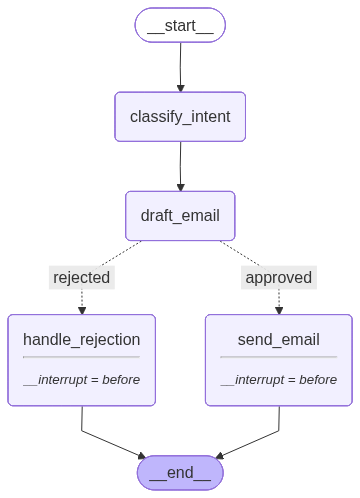

In [11]:
# ── 8. Visualize ──────────────────────────────────────────
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


## 9. The update_state Power Move
app.update_state() lets you write directly into the frozen state before resuming. This is how humans inject their decision back into the graph:



```
# Write human's decision into the paused state
app.update_state(config, {"approved": True})

# You can update ANY field — even override the draft
app.update_state(config, {
    "approved":   True,
    "email_draft": "Dear Customer, here is my edited version..."
})

# Then resume
app.invoke(None, config)
```



## 10. Inspecting the Frozen State

```
# Peek at the frozen state while the graph is paused
snapshot = app.get_state(config)

print(snapshot.values["email_draft"])  # see the draft
print(snapshot.next)                   # see which node runs next
# Output: ('send_email',)
```



## 11. Key Takeaways


```
interrupt_before=[node]  → freeze BEFORE that node runs
interrupt_after=[node]   → freeze AFTER that node runs
MemorySaver              → stores frozen state in RAM
thread_id                → session ID linking invoke() calls

Flow:
  invoke(initial_state, config)  → runs until interrupt, freezes
  app.update_state(config, {...})→ human writes decision into state
  invoke(None, config)           → resumes from frozen point

Without checkpointer → interrupts don't work (nowhere to save state)
Without thread_id    → LangGraph can't find the right frozen run```


